Time column is increasing: True
Missing values:
time    0
0_x     0
dtype: int64


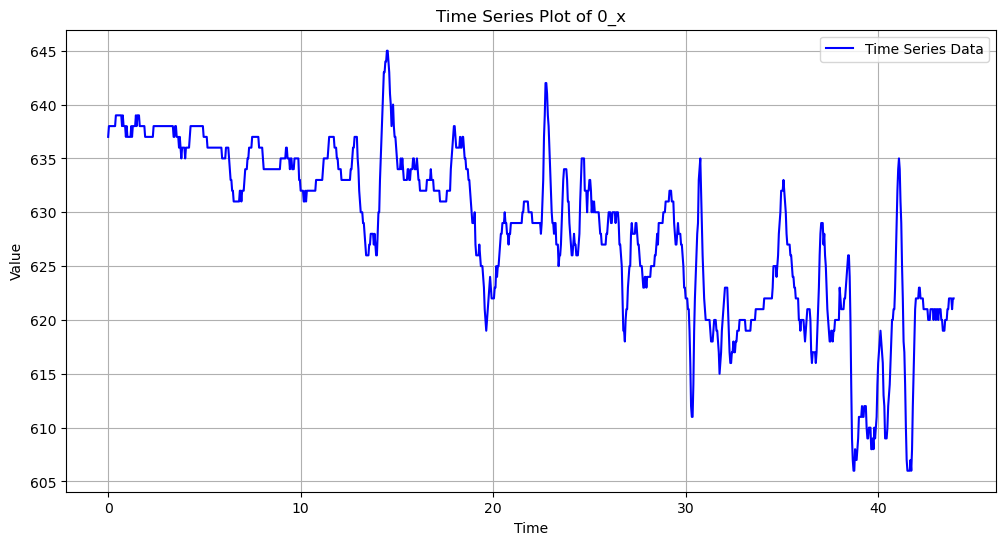

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Veri Setini Yükleme
df = pd.read_csv("data/lip_0_x.csv")

# 2. Zaman Serisi Doğrulama
print("Time column is increasing:", df['time'].is_monotonic_increasing)
print("Missing values:")
print(df.isnull().sum())

# 3. Zaman Serisi Görselleştirme
plt.figure(figsize=(12, 6))
plt.plot(df['time'], df['0_x'], label="Time Series Data", color="blue")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Time Series Plot of 0_x")
plt.legend()
plt.grid(True)
plt.show()

In [2]:
# 4. ADF Durağanlık Testi
adf_test = adfuller(df['0_x'])
print("ADF Statistic:", adf_test[0])
print("p-value:", adf_test[1])
print("Critical Values:", adf_test[4])

ADF Statistic: -2.1645442528685397
p-value: 0.2193645005987338
Critical Values: {'1%': -3.4364137337554785, '5%': -2.864217382986235, '10%': -2.568195530545688}


In [3]:
# 5. Durağanlık İçin Fark Alma İşlemi
df['0_x_diff'] = df['0_x'].diff()
adf_test_diff = adfuller(df['0_x_diff'].dropna())
print("ADF Statistic after differencing:", adf_test_diff[0])
print("p-value after differencing:", adf_test_diff[1])

ADF Statistic after differencing: -11.978892038028363
p-value after differencing: 3.745100821121786e-22


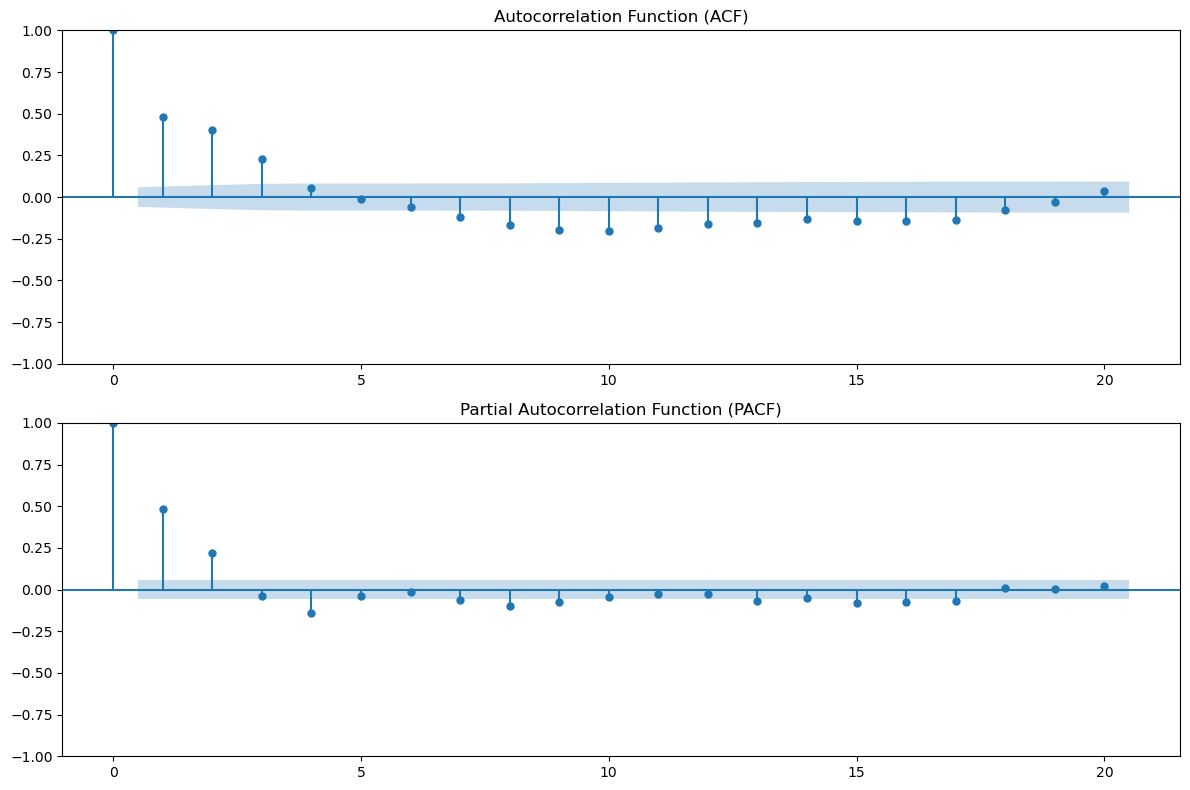

In [4]:
# 6. ACF ve PACF Grafikleri
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df['0_x_diff'].dropna(), ax=ax[0], lags=20)
ax[0].set_title("Autocorrelation Function (ACF)")
plot_pacf(df['0_x_diff'].dropna(), ax=ax[1], lags=20)
ax[1].set_title("Partial Autocorrelation Function (PACF)")
plt.tight_layout()
plt.show()

                               SARIMAX Results                                
Dep. Variable:                    0_x   No. Observations:                 1099
Model:               SARIMAX(1, 1, 1)   Log Likelihood               -1433.171
Date:                Wed, 12 Mar 2025   AIC                           2872.342
Time:                        00:38:23   BIC                           2887.346
Sample:                             0   HQIC                          2878.019
                               - 1099                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7009      0.031     22.328      0.000       0.639       0.762
ma.L1         -0.2805      0.040     -6.954      0.000      -0.360      -0.201
sigma2         0.7964      0.025     31.756      0.0

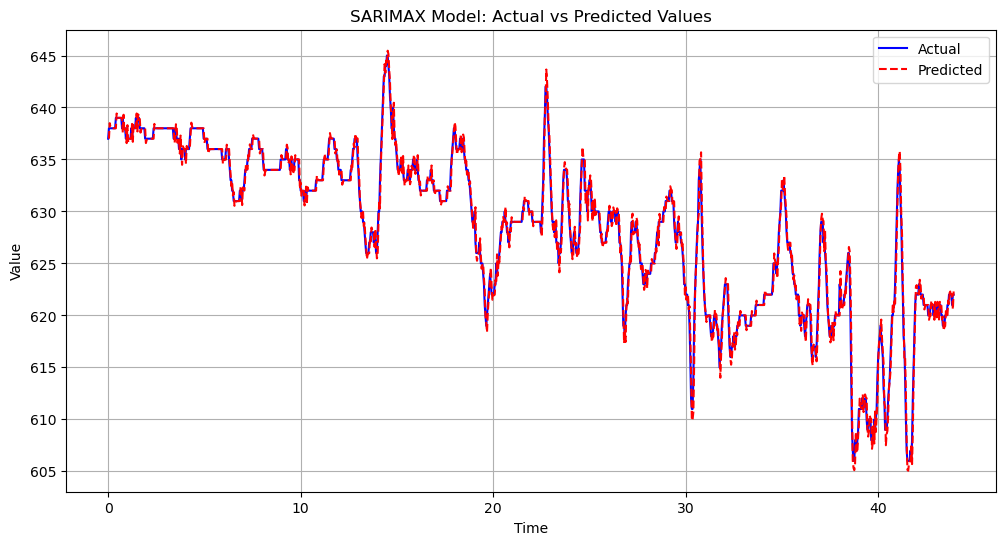

In [5]:
# 7. SARIMAX Modelini Uygulama
model = SARIMAX(df['0_x'], order=(1, 1, 1), seasonal_order=(0, 0, 0, 0), exog=None)  # SARIMAX(1,1,1)(0, 0, 0, 0) modeli
model_fit = model.fit()
print(model_fit.summary())

# 8. Tahminlerin Görselleştirilmesi
df['predictions'] = model_fit.predict(start=1, end=len(df), dynamic=False)
plt.figure(figsize=(12, 6))
plt.plot(df['time'], df['0_x'], label="Actual", color="blue")
plt.plot(df['time'], df['predictions'], label="Predicted", linestyle="dashed", color="red")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("SARIMAX Model: Actual vs Predicted Values")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
# 9. Performans Metriklerini Hesaplama
actual_values = df['0_x'][1:].values  # İlk fark alınan değer kaybolduğu için 1'den itibaren alıyoruz.
predicted_values = df['predictions'][1:].values

mae = mean_absolute_error(actual_values, predicted_values)
mse = mean_squared_error(actual_values, predicted_values)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((actual_values - predicted_values) / actual_values)) * 100

print("Gerçek Değerler vs Tahmin Edilen Değerler:")
for i in range(len(actual_values)):
    print(f"Gerçek: {actual_values[i]}, Tahmin: {predicted_values[i]}")

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")

Gerçek Değerler vs Tahmin Edilen Değerler:
Gerçek: 638, Tahmin: 637.0003368329517
Gerçek: 638, Tahmin: 638.492824948605
Gerçek: 638, Tahmin: 638.1354985437309
Gerçek: 638, Tahmin: 638.0379508881052
Gerçek: 638, Tahmin: 638.0106447393789
Gerçek: 638, Tahmin: 638.0029860516884
Gerçek: 638, Tahmin: 638.0008376517123
Gerçek: 638, Tahmin: 638.0002349794835
Gerçek: 638, Tahmin: 638.0000659168481
Gerçek: 639, Tahmin: 638.0000184911074
Gerçek: 639, Tahmin: 639.4204228104126
Gerçek: 639, Tahmin: 639.1179377293174
Gerçek: 639, Tahmin: 639.0330840944492
Gerçek: 639, Tahmin: 639.0092808070145
Gerçek: 639, Tahmin: 639.0026034679285
Gerçek: 639, Tahmin: 639.0007303292962
Gerçek: 639, Tahmin: 639.0002048732289
Gerçek: 638, Tahmin: 639.0000574713902
Gerçek: 639, Tahmin: 637.5795984981364
Gerçek: 638, Tahmin: 639.3024858722696
Gerçek: 638, Tahmin: 637.6644362327336
Gerçek: 638, Tahmin: 637.9058670754963
Gerçek: 637, Tahmin: 637.9735936702946
Gerçek: 638, Tahmin: 636.5721748271874
Gerçek: 637, Tahmin: 6